# 09 — Model Comparison and Selection

**Goal:** Side-by-side comparison of all three models' accuracy per condition, discussion of
which performed best and whether performance differs meaningfully between indoor/outdoor, and
an explicit statement of the deployment decision.

**Deployment decision (fixed in advance, per the methodology doc):** regardless of which model
wins this comparison, the **decision tree** is selected for embedded deployment, due to its
straightforward translation into C (nested if/else) for standalone STM32 inference. The
comparison below is a genuine research finding — it is just not what determines what gets
deployed.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PREPROCESSED_DIR = Path("../data/preprocessed")
FIGURES_DIR = Path("../results/figures")

accuracy_table = pd.read_csv(PREPROCESSED_DIR / "model_accuracy_table.csv")
accuracy_table

,condition,model,accuracy,n_predictions
0,indoor,decision_tree,0.96,50
1,indoor,random_forest,0.96,50
2,indoor,logistic_regression,0.94,50


## Side-by-side accuracy comparison

In [2]:
pivot = accuracy_table.pivot(index="model", columns="condition", values="accuracy")
pivot = pivot.sort_values("indoor", ascending=False)
pivot

condition,indoor
model,
decision_tree,0.96
random_forest,0.96
logistic_regression,0.94


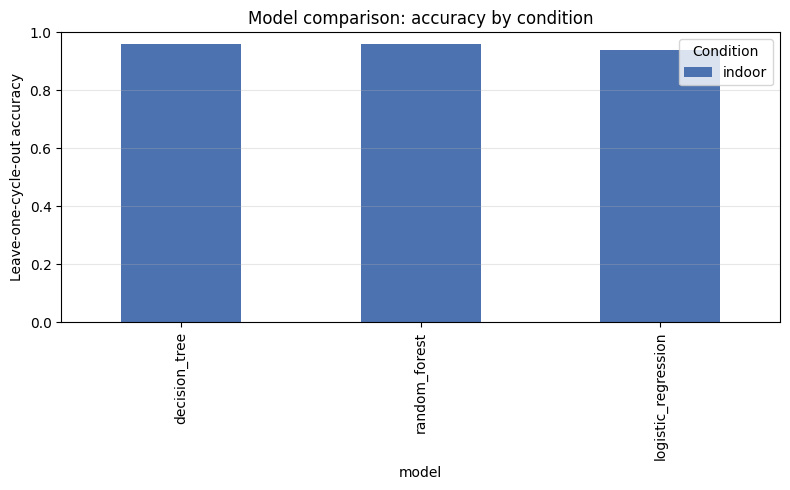

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"])
ax.set_ylabel("Leave-one-cycle-out accuracy")
ax.set_title("Model comparison: accuracy by condition")
ax.set_ylim(0, 1)
ax.legend(title="Condition")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_model_comparison.png", dpi=120)
plt.show()

## Discussion notes (fill in after real data)

- Which model performed best per condition?
- Is there a meaningful indoor vs. outdoor performance gap? If so, does that suggest one
  environment is inherently harder to forecast (e.g., outdoor's higher variance in
  temperature/light/humidity)?
- Any surprises relative to the feature importance plot from notebook 07?
- With only ~5–9 cycles per condition, are these accuracy differences large enough to be
  meaningful, or within the range you'd expect from noise given the small N? (Worth being
  honest about this rather than over-reading small differences.)

In [4]:
# Placeholder for your team's written discussion once real results are in.
discussion_notes = """
[Fill in after running on real collected data]

Best performing model overall: ...
Indoor vs outdoor accuracy gap: ...
Notable feature importance findings: ...
Any classes with especially poor recall (e.g., 'Soon' being confused with 'Urgent'): ...
"""
print(discussion_notes)


[Fill in after running on real collected data]

Best performing model overall: ...
Indoor vs outdoor accuracy gap: ...
Notable feature importance findings: ...
Any classes with especially poor recall (e.g., 'Soon' being confused with 'Urgent'): ...



## Deployment decision (explicit statement)

**Decision: Decision Tree is selected for embedded deployment**, regardless of the comparison
above.

**Justification:**
1. **Interpretability** — the learned splits can be read directly as human-understandable rules,
   useful for both debugging on-device behavior and explaining the system in the report.
2. **Trivial C-portability** — a shallow decision tree translates directly into nested
   `if`/`else` statements, requiring no floating-point matrix operations (unlike logistic
   regression's weighted sum) and no ensemble-voting logic across many trees (unlike random
   forest).
3. **No dependency on model size at deployment** — a random forest winning evaluation would
   require either porting many trees (large code footprint, more transcription risk) or
   retraining a much smaller forest specifically for deployment, which would mean deploying a
   different model than the one evaluated. The decision tree avoids this problem entirely.

This decision was fixed during methodology design, before seeing results, specifically to avoid
the deployment choice being driven by whichever model happens to win on a small evaluation set.

**Next step:** `10_decision_tree_export_for_deployment.ipynb` — export the final tree's structure and translate it into C for the STM32.